This notebook is to check the credit spread, stock is a risk asset, to support rally, market should be on risk on mode and thus credit spread should be tight.

One of the indicator is to check IG vs treasury bond. for example the ETF LQD vs IEF both have a duration around 8years. 

In [1]:
import sys

sys.path.append("../../../src/")
from sts.data.dapi import Ticker
from sts.plots.time_series_plots import plot_multi_time_series
import numpy as np
import pandas as pd
from sts.quant.indicators.trend import get_trend_score
from sts.quant.indicators.volatility import get_vol_atr_scaled
from sts.optimization.corr_max import get_optimal_horizon_max_corr

In [2]:
def get_price_ratio(
    target_sym: str,
    ratio_sym1: str,
    ratio_sym2: str,
    history_params: dict,
    index_transform=None,
):
    columns = ["Open", "High", "Low", "Close"]

    def get_ts(sym):
        ticker_sym = Ticker(sym)
        df_sym = ticker_sym.history(**history_params)[columns]
        if index_transform is not None:
            df_sym.index = index_transform(df_sym.index)
        return df_sym

    df_target = get_ts(target_sym)
    df_sym1 = get_ts(ratio_sym1)
    df_sym2 = get_ts(ratio_sym2)
    df_ratio_sym1_sym2 = df_sym1 / df_sym2
    df_ratio_sym1_sym2.name = "%s/%s" % (ratio_sym1, ratio_sym2)

    return df_target, df_ratio_sym1_sym2

In [15]:
period = "10Y"
df_target, df_ratio = get_price_ratio("SPY", "LQD", "IEF", dict(period=period))

/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:771: FutureWarning:

The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.

/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:771: FutureWarning:

The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.

/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:771: FutureWarning:

The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.



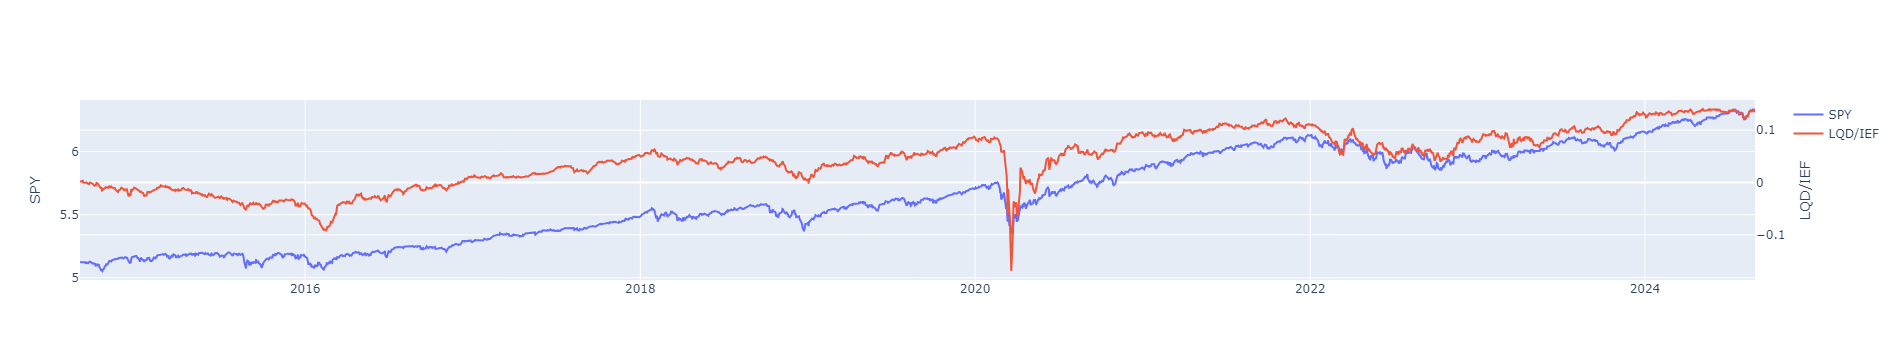

In [16]:
plot_multi_time_series(
    [np.log(df_target["Close"]), np.log(df_ratio["Close"])],
    name_list=["SPY", "LQD/IEF"],
    yaxis_list=["y1", "y2"],
    yaxis_left=[True, False],
)

In [17]:
corr_list = get_optimal_horizon_max_corr(df_target, df_ratio, scan_window=[5, 10, 20, 60, 200], zscore_cap=3.0)

In [18]:
np.round(corr_list, 3)

array([[ 60.   ,   0.843],
       [ 20.   ,   0.79 ],
       [ 10.   ,   0.714],
       [200.   ,   0.693],
       [  5.   ,   0.644]])

In [19]:
df_ratio_trend = get_trend_score(df_ratio, 20)
spy_trend = get_trend_score(df_target, 20)

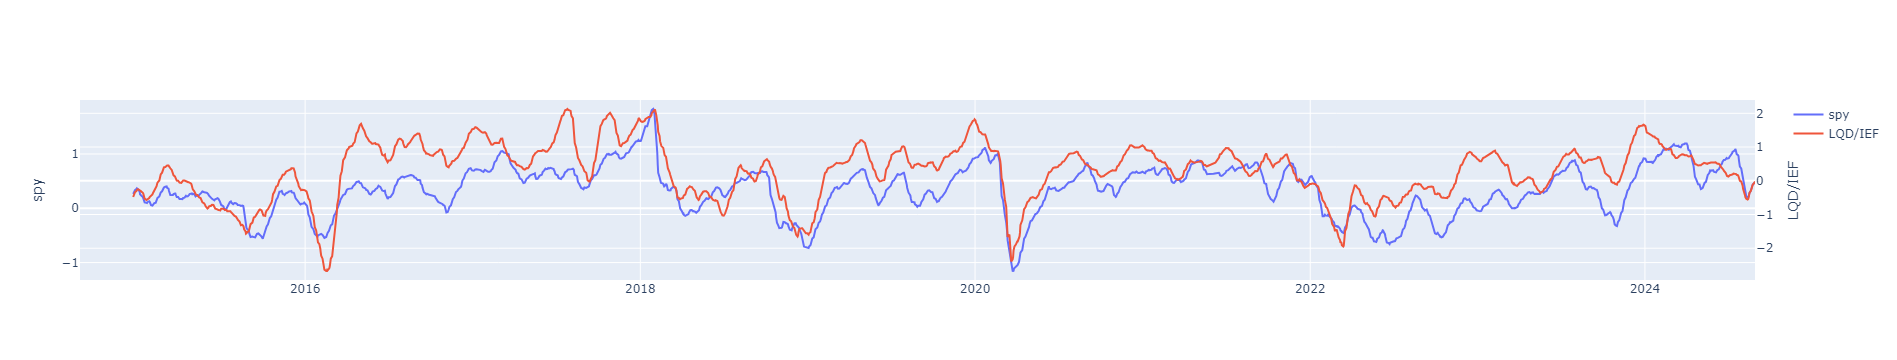

In [20]:
plot_multi_time_series(
    [spy_trend, df_ratio_trend],
    name_list=["spy", "LQD/IEF"],
    yaxis_list=["y1", "y2"],
    yaxis_left=[True, False],
)

In [21]:
spy_vol = get_trend_score(get_vol_atr_scaled(df_target, 20), 5)
ratio_vol = get_trend_score(get_vol_atr_scaled(df_ratio, 20), 5)

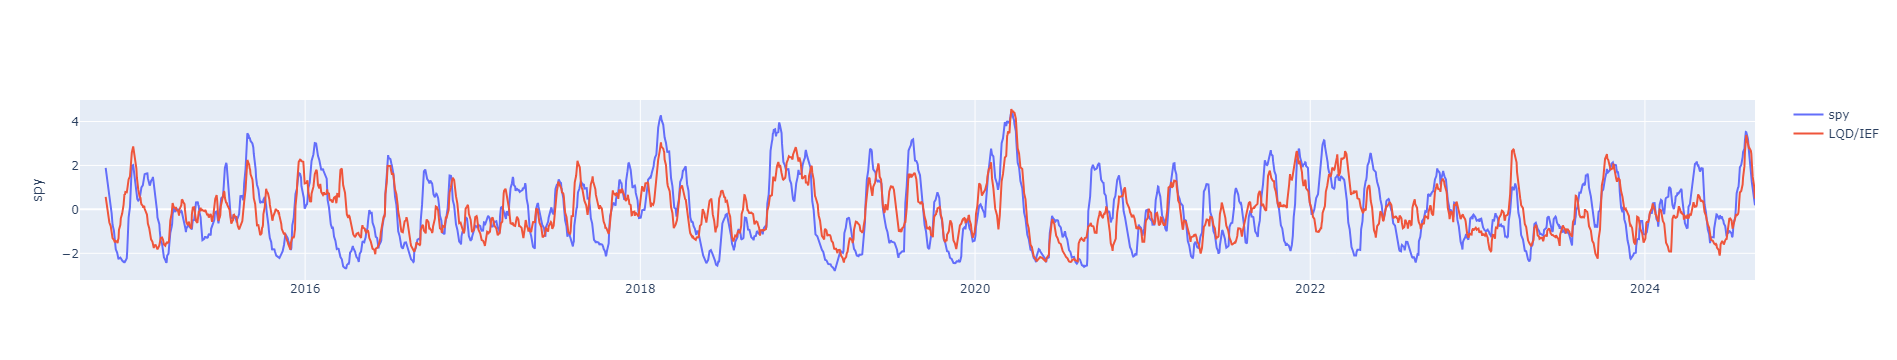

In [22]:
plot_multi_time_series(
    [spy_vol, ratio_vol],
    name_list=["spy", "LQD/IEF"],
    yaxis_list=["y1", "y1"],
    yaxis_left=[True, True],
)

find indicator with prediction power. 